In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import tqdm
from matplotlib import pyplot as plt
import random
import os

In [12]:
# Load the data, using tiny shakespeare
input_file_path = '../data/tinyshakespeare.txt'
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

if not os.path.exists(input_file_path):
    with open(input_file_path, 'w') as f:
        f.write(requests.get(data_url).text)
    
with open(input_file_path, 'r') as f:
    corpus = f.read()

In [13]:
# Character level "tokenizer"
unique_chars = sorted(list(set(corpus)))

stoi = {ch: i for i, ch in enumerate(unique_chars)} # str to int
itos = {i: ch for i, ch in enumerate(unique_chars)} # int to str

def encode(text: str) -> list[int]:
    return [stoi[char] for char in text]

def decode(tokens: list[int]) -> str:
    return ''.join([itos[token] for token in tokens])

# Encode the corpus and convert to tesnor
data = torch.tensor(encode(corpus), dtype=torch.long)

In [14]:
# Split the data
n = len(data)
train_frac = int(0.9 * n)
train_data = data[:train_frac]
test_data = data[train_frac:]

In [15]:
# Get batches
def get_batch(data, batch_size: int, seq_len: int):
    """Get a batch of (x, y) data from the corpus

    Args:
        data: 1D tensor of torch.long containing the corpus tokens
        batch_size (int): The number of samples to get
        seq_len (int): The length of each sequence to fetch
        
    Returns:
        X: a 2D tensor of shape (batch_size, seq_len) containing token IDs
        Y: a 2D tensor of shape (batch_size, seq_len) containing token IDs
    """
    n = len(data)
    if seq_len > n:
        raise ValueError('seq_len is larger than size of corpus')
    
    start_idxs = torch.randint(n - seq_len, (batch_size,))
    start_idxs = start_idxs[:, None]
    range_idxs = torch.arange(seq_len + 1)
    idxs = start_idxs + range_idxs
    
    values = data[idxs]
    X, Y = values[:, :-1], values[:, 1:]
    return X, Y

In [24]:
# Create a single head
class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, head_size):
        """
        Args: 
            d_model (int): Length of the hidden vector after embedding
            head_size (int): The size of the attention head
        """
        super().__init__()

        self.head_size = head_size
        
        self.w_q = nn.Linear(d_model, head_size, bias=False) # Query 
        self.w_k = nn.Linear(d_model, head_size, bias=False) # Key
        self.w_v = nn.Linear(d_model, head_size, bias=False) # Value
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model) that 
            contains the embedded tokens added with the positional encoding
            
        Returns:
            A tensor of shape (batch_size, seq_len, head_size)
        """
        # Construct q, k, v matrices
        q = self.w_q(x) # (batch_size, seq_len, head_dim)
        k = self.w_k(x)
        v = self.w_v(x)
        
        # Similarity matrix
        sim = q @ k.transpose(-2, -1) # (batch_size, seq_len, seq_len)
        sim = self.head_size ** -0.5 * sim
        
        # Apply causal mask
        seq_len = sim.shape[-1]
        mask = torch.tril(torch.ones(seq_len, seq_len)) # Lower triangular
        sim.masked_fill_(mask == 0, float('-inf'))
        
        # Softmax
        sim = F.softmax(sim, dim=-1)
        
        # Output
        output = sim @ v
        return output

In [25]:
# Combine the heads inefficiently first with a for loop
class MultiheadAttentionLooped(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, context_size):
        """
        Args: 
            vocab_size (int): Vocabulary size
            d_model (int): Length of the hidden vector after embedding
            num_heads (int): The number of attention heads, must be 
                <= d_model
            context_size (int): The max context size 
        """
        super().__init__()
        
        # Check preconditions
        if num_heads > d_model:
            raise ValueError('num_heads must be <= d_model')
        
        # Embedding
        self.embed = nn.Embedding(vocab_size, d_model)
        
        # Positional Encoder
        self.context_size = context_size
        self.pos_encoder = nn.Embedding(context_size, d_model)
        
        # Attention
        head_size = d_model // num_heads
        self.heads = nn.ModuleList()
        for _ in range(num_heads):
            self.heads.append(SingleHeadAttention(d_model, head_size))
        self.w_o = nn.Linear(num_heads * head_size, d_model, bias=False) # Mix heads
        
        # Unembedding
        self.unembed = nn.Linear(d_model, vocab_size, bias=False)
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len) that contains
            the token ids for each token
            
        Returns:
            A tensor of shape (batch_size, seq_len, vocab_size) of logits
        """
        # Check seq_len size
        if x.shape[1] > self.context_size:
            raise ValueError('The sequence length is larger than the max context size')
        
        # Embedding
        x_embeded = self.embed(x) # (batch_size, seq_len, d_model)
        
        # Positional Encoding
        positions = torch.arange(x.shape[1]).expand(x.shape[0], x.shape[1])
        positions_encoded = self.pos_encoder(positions)
        
        # Combine
        hidden = x_embeded + positions_encoded
        
        # Run attention on each head
        head_ouputs = []
        for head in self.heads:
            head_ouputs.append(head(hidden))
        out = torch.cat(head_ouputs, dim=-1)
        out = self.w_o(out)
        
        # Unembedding
        unembeded = self.unembed(out)
        return unembeded
    

In [26]:
# Train the model
vocab_size = len(unique_chars)
batch_size = 64
seq_len = 128
d_model = 128
num_heads = 8
total_steps = 7000
context_size = seq_len

model = MultiheadAttentionLooped(vocab_size, d_model, num_heads, context_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.e-3)

losses = []
seq_done = 0

pbar = tqdm.tqdm(range(total_steps))
for step in pbar:
    x, y = get_batch(train_data, batch_size, seq_len)
    optimizer.zero_grad()
    
    logits = model(x)
    logits = logits.reshape(-1, logits.size(-1))
    y = y.reshape(-1)
    
    loss = criterion(logits, y)
    loss.backward()
    
    losses.append(loss.item())
    seq_done += batch_size
    
    pbar.set_description(f'Loss: {loss.item():.4f}, Sequences Done: {seq_done}')
    
    optimizer.step()
    

Loss: 1.7690, Sequences Done: 448000: 100%|██████████| 7000/7000 [02:30<00:00, 46.39it/s]


Text(0, 0.5, 'Loss')

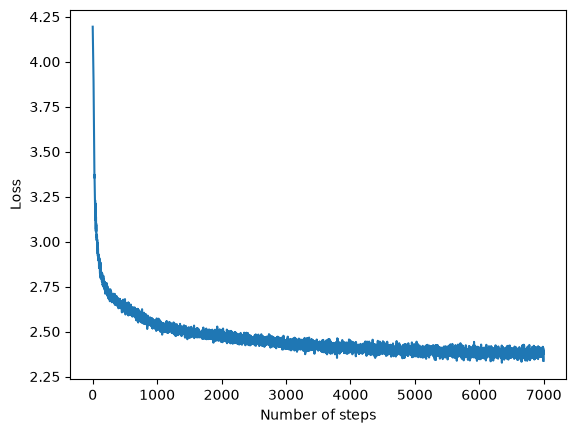

In [8]:
# Graph the results
plt.plot(np.linspace(0, total_steps-1, total_steps), losses)
plt.xlabel('Number of steps')
plt.ylabel('Loss')

In [28]:
# Autoregressive generation
tokens_to_gen = 200
random_char = unique_chars[random.randint(0, vocab_size-1)]
start_token = encode(random_char)[0]

generated_tokens = []
generated_tokens.append(start_token)

for _ in range(tokens_to_gen-1):
    with torch.no_grad():
        logits = model(torch.tensor(generated_tokens[-context_size:]).reshape(1, -1))
        logits = logits[0, -1, :] # (vocab,)
        probs = F.softmax(logits, dim=-1)
        token = torch.multinomial(probs, num_samples=1) # Sampling
        generated_tokens.append(token.item())
    
decode(generated_tokens)

'3\nNOKLEHND IETYRUTDUS:\nWhat be Inam astrant will fear vintands:\nIt beasty; reath my nay, hather up neant: I port,\nIn conntired heim andy one the sint theardiee\nbe gazen: a bowr gai monoulder-wether,\nN'